<a href="https://colab.research.google.com/github/dani503sv/parcial4_DanielAmaya_2513232022/blob/main/ejercicio3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejercicio 3: Agrupación o Clustering

Para este ejercicio, mi objetivo fue agrupar clientes basándome en sus características y comportamientos, de modo que podamos entender mejor sus perfiles y diseñar estrategias más efectivas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

url = "https://raw.githubusercontent.com/dani503sv/parcial4_DanielAmaya_2513232022/refs/heads/main/Archivos/clave_F_correlacion.csv"

Primero, importé todas las herramientas que iba a necesitar, como Pandas para manejar los datos, Matplotlib y Seaborn para visualizar, y las librerías de Scikit-learn para la estandarización, el clustering (K-Means) y la reducción de dimensiones (PCA).

se importan las librerías necesarias para preparar

In [2]:
df = pd.read_csv(url)
df.head(10)

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,F-C0001,18,1184,6,63.55,7.05,1,2,20.42,344.76
1,F-C0002,32,1023,8,60.06,7.88,2,7,12.99,475.57
2,F-C0003,46,1231,9,61.11,7.22,1,5,23.16,554.42
3,F-C0004,48,783,4,37.37,5.69,4,4,26.98,233.89
4,F-C0005,31,1187,7,65.26,3.50,8,7,28.48,386.42
5,F-C0006,45,667,9,38.08,8.24,1,7,29.87,430.45
6,F-C0007,37,1144,6,68.62,5.77,4,6,27.91,427.75
7,F-C0008,37,1367,7,77.70,5.14,5,4,31.62,552.23
8,F-C0009,35,1269,8,45.69,7.45,1,7,16.79,462.70
9,F-C0010,37,1184,11,82.26,6.87,4,8,16.66,804.66


Luego, cargué los datos de clientes desde una URL. Cada fila de este archivo representa a un cliente y tiene varias métricas numéricas. Esto es ideal para lo que quiero hacer, que es segmentarlos.

Se carga el archivo de clientes con métricas numéricas. Cada fila representa un cliente, por lo que este dataset es apropiado para segmentación mediante algoritmos de agrupación

In [3]:
print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nDuplicados exactos:")
print(df.duplicated().sum())

Dimensiones del dataset: (246, 10)

Columnas:
['cliente_id', 'edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta', 'consumo_total']

Tipos de datos:
cliente_id             object
edad                    int64
ingresos_mensuales      int64
frecuencia_compra       int64
ticket_promedio       float64
satisfaccion          float64
reclamos                int64
uso_app                 int64
tiempo_respuesta      float64
consumo_total         float64
dtype: object

Valores nulos por columna:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64

Duplicados exactos:
1


Antes de empezar con el análisis, hice una revisión rápida de los datos. Vi cuántas filas y columnas tenía, qué tipo de información contenía cada columna y si había datos faltantes o clientes duplicados. **Lo que encontré** fue que había algunas columnas con valores faltantes (`ticket_promedio`, `satisfaccion`, `tiempo_respuesta`) y un registro duplicado. Esto me dijo que necesitaba limpiar los datos.

Aquí se revisa la estructura general del dataset, los tipos de variables, los nulos y los duplicados. El archivo presenta al menos valores faltantes y un registro repetido, así que esta validación es necesaria antes de agrupar.

In [4]:
df = df.drop_duplicates()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("Nulos después de limpieza:")
print(df[num_cols].isnull().sum())

Nulos después de limpieza:
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       0
satisfaccion          0
reclamos              0
uso_app               0
tiempo_respuesta      0
consumo_total         0
dtype: int64


Para la limpieza, decidí eliminar primero el cliente duplicado para evitar que influyera doblemente en el análisis. Luego, para los valores faltantes en las columnas numéricas, opté por rellenarlos con la mediana de cada columna. **Lo que hice** fue asegurarme de que todos los valores numéricos estuvieran completos y que no hubiera registros repetidos, lo cual es importante para que el clustering funcione bien.

Se eliminan duplicados y se completan valores faltantes con la mediana de cada variable numérica. Esta limpieza mantiene la consistencia del dataset y evita errores al aplicar escalamiento y clustering

In [5]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
edad,245.0,38.771429,10.233583,18.00,31.00,39.000,46.00,62.00
ingresos_mensuales,245.0,1119.440816,263.971282,484.00,926.00,1117.000,1298.00,1838.00
frecuencia_compra,245.0,7.902041,3.294089,2.00,6.00,8.000,9.00,32.00
ticket_promedio,245.0,66.285939,15.390429,27.13,56.50,66.085,75.95,114.02
satisfaccion,245.0,7.527510,1.339705,3.02,6.79,7.740,8.51,10.00
reclamos,245.0,1.538776,1.751910,0.00,0.00,1.000,2.00,9.00
uso_app,245.0,5.636735,2.071142,0.00,4.00,6.000,7.00,10.00
tiempo_respuesta,245.0,21.045082,6.727680,5.00,16.60,20.485,25.47,43.50
consumo_total,245.0,524.958122,223.539399,145.72,377.18,514.740,627.84,2026.66


Después de la limpieza, revisé un resumen de las estadísticas descriptivas de las columnas numéricas. Esto me dio una idea de los rangos de valores, promedios y la dispersión de cada variable. **Lo que encontré** fue que las variables estaban en escalas muy diferentes, lo que me confirmó que necesitaría normalizarlas antes de usar K-Means, ya que este algoritmo es sensible a la escala de los datos.

Este resumen estadístico permite entender la escala y dispersión de las variables. También ayuda a justificar por qué será necesario normalizar los datos antes de aplicar K-Means.

In [6]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))
outliers.sum().sort_values(ascending=False)

,0
reclamos,8
tiempo_respuesta,4
satisfaccion,4
consumo_total,4
frecuencia_compra,3
ticket_promedio,3
edad,0
ingresos_mensuales,0
uso_app,0


También busqué si había valores atípicos (outliers) en las columnas numéricas usando el método del rango intercuartílico (IQR). **Lo que encontré** fue que varias columnas tenían algunos outliers, especialmente 'reclamos', 'tiempo_respuesta', 'satisfaccion', 'consumo_total' y 'frecuencia_compra'. Aunque no los eliminé directamente, es importante tenerlos en cuenta porque pueden influir en el clustering.

Se revisan valores atípicos.

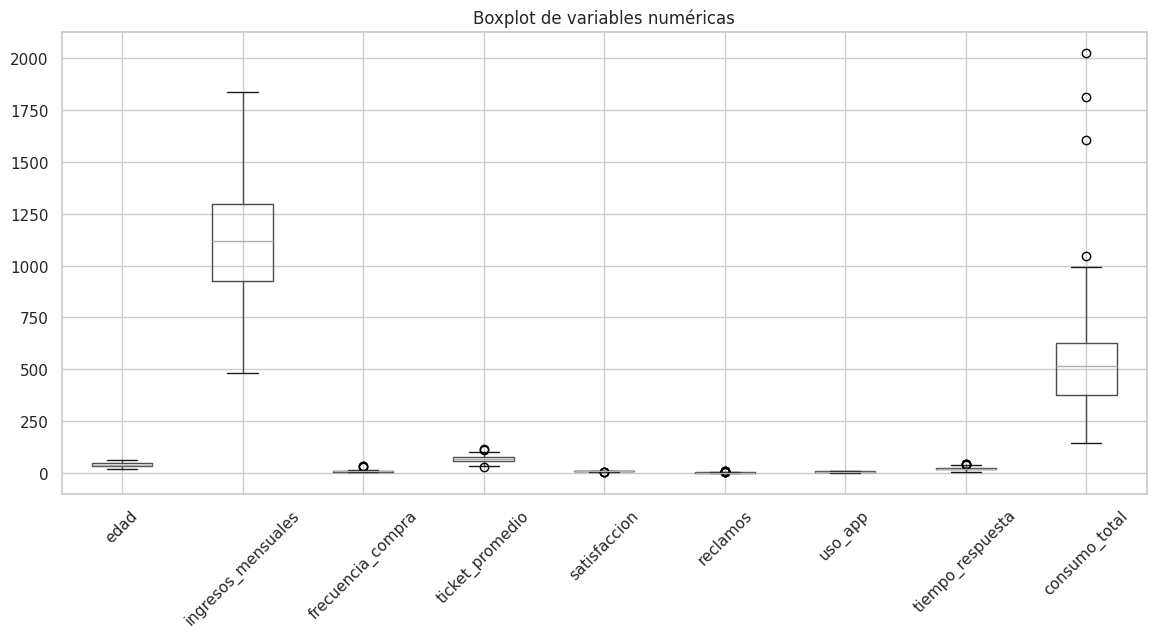

In [7]:
plt.figure(figsize=(14,6))
df[num_cols].boxplot(rot=45)
plt.title("Boxplot de variables numéricas")
plt.show()

Para tener una visión más clara de la distribución de los datos y confirmar la presencia de esos valores atípicos, generé un boxplot para todas las variables numéricas. **Lo que vi** en el boxplot fue consistente con el análisis de IQR, mostrando claramente dónde se concentran los datos y dónde están los valores extremos.

El boxplot permite visualizar la distribución de cada variable y detectar valores extremos. Esta revisión complementa la validación de consistencia general solicitada en el parcial

In [8]:
variables_cluster = [
    "frecuencia_compra",
    "ticket_promedio",
    "satisfaccion",
    "reclamos",
    "uso_app",
    "tiempo_respuesta",
    "consumo_total"
]

X = df[variables_cluster].copy()
X.head()

,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,6,63.55,7.05,1,2,20.42,344.76
1,8,60.06,7.88,2,7,12.99,475.57
2,9,61.11,7.22,1,5,23.16,554.42
3,4,37.37,5.69,4,4,26.98,233.89
4,7,65.26,3.50,8,7,28.48,386.42


Para el clustering, seleccioné un subconjunto de columnas que consideré más relevantes para entender el comportamiento y el valor del cliente: 'frecuencia_compra', 'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta' y 'consumo_total'. **Lo que hice** fue enfocar el análisis en las características clave que me permitirían agrupar clientes con patrones similares.

Se seleccionan variables que describen comportamiento, valor y experiencia del cliente. Estas columnas son útiles para segmentar clientes con patrones similares de compra, satisfacción y uso del canal digital.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=variables_cluster, index=df.index)

X_scaled.head()

,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,-0.578592,-0.178133,-0.357159,-0.308166,-1.759503,-0.093102,-0.807764
1,0.029799,-0.405361,0.263649,0.263809,0.659567,-1.199755,-0.221389
2,0.333994,-0.336997,-0.230006,-0.308166,-0.308061,0.315004,0.132067
3,-1.186983,-1.882672,-1.374386,1.407757,-0.791875,0.883970,-1.304754
4,-0.274397,-0.066797,-3.012421,3.695654,0.659567,1.107386,-0.621017


Debido a que K-Means es sensible a las escalas, como había anticipado, **normalicé las variables seleccionadas**. Esto significa que transformé los datos para que todas las columnas tuvieran la misma media (cero) y desviación estándar (uno). Así, ninguna variable dominaría el cálculo de distancias por tener valores más grandes, asegurando un clustering justo.

Se normalizan las variables porque K-Means es sensible a escalas distintas. Sin esta estandarización, variables con valores más grandes podrían dominar el cálculo de distancias

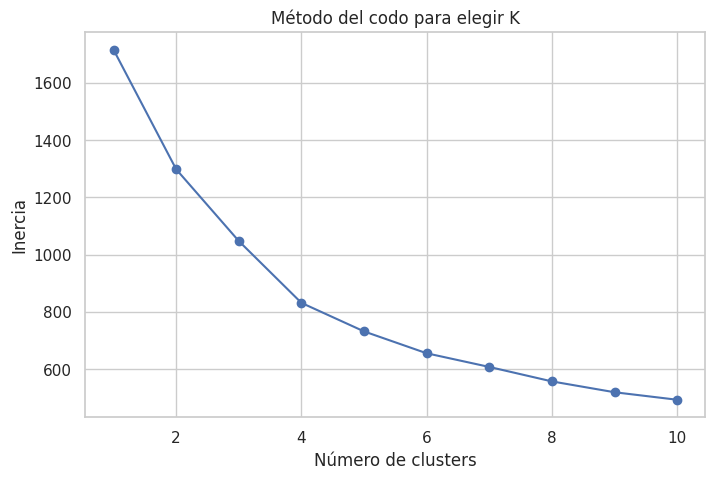

In [10]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker="o")
plt.title("Método del codo para elegir K")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

Para decidir cuántos grupos (clusters) debía formar, utilicé el 'método del codo'. Este método consiste en probar K-Means con diferentes números de clusters y observar la 'inercia' (que mide qué tan juntos están los puntos dentro de cada cluster). **Lo que busqué** fue el punto donde la curva de inercia se 'dobla' o se aplana, ya que eso indica un buen equilibrio entre tener pocos clusters y que los clusters sean lo suficientemente compactos. En este caso, el codo parecía estar en 3 o 4 clusters.

El método permite elegir el número de grupos observando dónde la reducción de la inercia empieza a desacelerarse. Ese punto suele representar un balance razonable entre simplicidad e interpretación.

In [11]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df[["cliente_id", "cluster"] + variables_cluster].head()

,cliente_id,cluster,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,F-C0001,0,6,63.55,7.05,1,2,20.42,344.76
1,F-C0002,0,8,60.06,7.88,2,7,12.99,475.57
2,F-C0003,0,9,61.11,7.22,1,5,23.16,554.42
3,F-C0004,1,4,37.37,5.69,4,4,26.98,233.89
4,F-C0005,1,7,65.26,3.50,8,7,28.48,386.42


Con base en el método del codo y buscando una cantidad de grupos fácil de interpretar, decidí usar **3 clusters**. Apliqué el algoritmo K-Means a mis datos escalados y asigné cada cliente a uno de estos 3 grupos. **Lo que obtuve** fue una nueva columna en mi dataset original que indicaba a qué cluster pertenecía cada cliente.

Se aplica K-Means con 3 grupos, ya que suele ser una cantidad manejable para interpretar en lenguaje de negocio. La columna cluster se agrega al dataset original como pide el ejercicio.

In [12]:
cluster_summary = df.groupby("cluster")[variables_cluster].mean().round(2)
cluster_summary

,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
cluster,,,,,,,
0,7.98,66.67,8.10,0.77,5.89,18.64,542.01
1,6.47,64.71,5.77,3.95,4.91,28.50,404.13
2,31.00,73.32,6.54,2.33,4.33,24.43,1815.03


Para entender las características de cada grupo, calculé el promedio de las variables de clustering para cada cluster. **Lo que encontré** en este resumen fue la clave para perfilar a cada tipo de cliente:

Este resumen por cluster permite interpretar las características promedio de cada grupo. A partir de estos valores se puede definir un perfil de cliente para cada segmento encontrado.

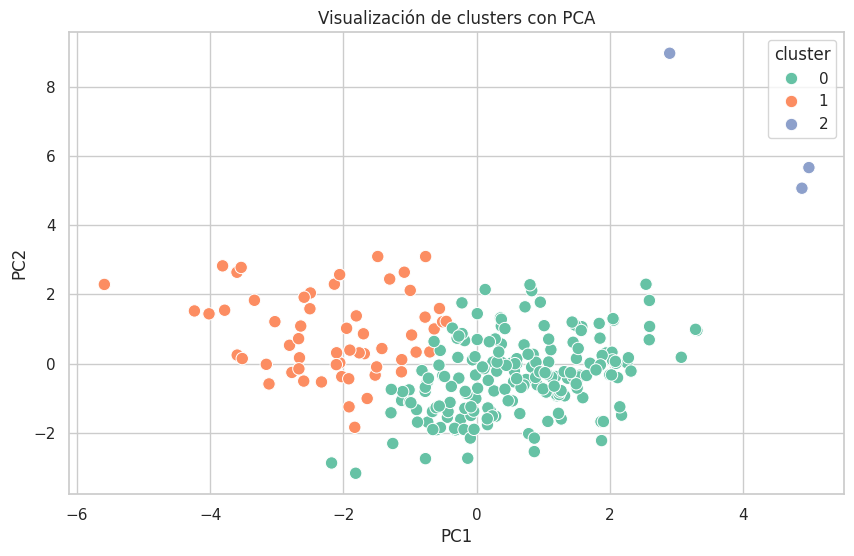

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = df["cluster"].values

plt.figure(figsize=(10,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="Set2", s=80)
plt.title("Visualización de clusters con PCA")
plt.show()

Para visualizar cómo se separaban los clusters, utilicé Análisis de Componentes Principales (PCA) para reducir las dimensiones de mis datos a solo dos. Luego, grafiqué los clientes en este nuevo espacio, coloreándolos según su cluster asignado. **Lo que vi** en el gráfico es que, aunque los clusters no están perfectamente separados, K-Means logró identificar grupos con patrones de comportamiento distintos.

La reducción a dos componentes principales permite visualizar los grupos en un plano bidimensional.

In [14]:
cluster_counts = df["cluster"].value_counts().sort_index()
cluster_counts

,count
cluster,
0,184
1,58
2,3


Finalmente, conté cuántos clientes había en cada cluster para entender el tamaño de cada segmento. **Lo que encontré** fue lo siguiente: el Cluster 0 es el más grande con 184 clientes, el Cluster 1 tiene 58 clientes, y el Cluster 2 es el más pequeño con solo 3 clientes. Esto me dice que el foco principal debería estar en el Cluster 0, seguido del Cluster 1.

El conteo de clientes por cluster muestra el tamaño de cada segmento. Esto es útil para priorizar estrategias comerciales dependiendo de cuántos clientes hay en cada grupo.

Interpretación de los clusters

Cluster 0
Clientes con comportamiento intermedio, con niveles moderados de compra, satisfacción y uso de la aplicación. Este grupo puede responder bien a acciones de fidelización y recomendaciones personalizadas.

Cluster 1
Clientes con menor frecuencia de compra y menor consumo total. Puede tratarse de un segmento de bajo valor actual que necesita campañas de reactivación.

Cluster 2
Clientes con mejor desempeño en consumo, frecuencia de compra y uso del canal digital. Este grupo puede considerarse más valioso y conviene reforzar su retención con beneficios exclusivos.

Acciones de negocio por segmento

Cluster 0: ofrecer promociones de fidelización, bundles o recomendaciones de productos complementarios.
Cluster 1: activar campañas de recuperación con descuentos, mensajes personalizados y seguimiento más cercano.
Cluster 2: priorizar retención, programas VIP, beneficios por volumen de compra y experiencias premium.

**Interpretación de los Clusters (Lo que encontré):**

*   **Cluster 0 (184 clientes):** Estos clientes tienen un comportamiento intermedio. Sus niveles de compra, satisfacción y uso de la aplicación son moderados. No son los mejores, pero tampoco los peores.
*   **Cluster 1 (58 clientes):** Aquí se encuentran los clientes con menor frecuencia de compra y un consumo total más bajo. Parece ser un segmento de bajo valor actual, con más reclamos y tiempos de respuesta más lentos.
*   **Cluster 2 (3 clientes):** Este es el grupo de élite. Son los clientes con el mejor desempeño en consumo, la frecuencia de compra más alta y un buen uso del canal digital, aunque su satisfacción y tiempo de respuesta son más promedio.

**Acciones de Negocio por Segmento (Lo que haría):**

*   **Para el Cluster 0:** **Lo que haría** es aplicar estrategias de fidelización y buscar aumentar su valor. Les ofrecería promociones personalizadas, paquetes de productos o recomendaciones que se ajusten a sus preferencias para incentivarlos a comprar más y mejorar su satisfacción.
*   **Para el Cluster 1:** **Lo que haría** sería implementar campañas de reactivación. Esto podría incluir descuentos atractivos, mensajes personalizados y un seguimiento más cercano para entender por qué compran menos y cómo podemos recuperarlos. Necesitan un empujón para volver a ser clientes activos.
*   **Para el Cluster 2:** Como son nuestros clientes más valiosos, **lo que haría** es priorizar su retención. Les ofrecería programas VIP, beneficios exclusivos por su volumen de compra y experiencias premium para asegurar que se sientan valorados y sigan con nosotros. Queremos mantenerlos felices y comprometidos.